# <span style="color: purple;">Lesson 10 - Image Classification</span>

**Developers:** Aditya & Brian | **Reviewers:** Alina

---

## <span style="color: purple;">🎯 Learning Objectives</span>

By the end of this lesson, you will have:

- Loaded and explored a real-world image dataset (CIFAR-10)
- Understood the structure of colour images (**RGB channels**)
- Linked the idea of individual pixel values to "features" (💪 as in previous lessons)
- Trained a simple "flat" model and a **Convolutional Neural Network (CNN)**
- Compared how each architecture performs on identifying complex objects like cars and aeroplanes

<div class="alert alert-info">

**How it works:** Click the ▶ button on the top left of each code cell, top to bottom. Read the explanation after you see the output. That's it!

</div>

In [1]:
# ───────────────────────────────────────────────────────────
# Setup cell — run this first, then you can ignore it
# ───────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm

print("✓ Ready to go!")

✓ Ready to go!


---

## <span style="color: purple;">🎨 The Mathematical Representation of a Colour Image</span>

### From pixels to numbers

Every digital image is made up of tiny squares called **pixels**. If you zoom in far enough on any photo, you will see them — a grid of individual coloured dots. The count of pixels in an image is known as the resolution.

Each pixel has a single colour but mathematically it is a **3 separate numbers**, one for the intensity of each primary colour - Red, Green, Blue.

So a single pixel is just 3 numbers, and an entire image is a **grid of pixels** — which means the whole image is really just a **3 grids (with dimension defined by the resolution) of numbers** stacked together.

<img src="https://upload.wikimedia.org/wikipedia/commons/b/b4/Rgb-raster-image.svg" alt="RGB channels diagram showing how Red, Green, and Blue layers combine to form a colour image" width="500" style="margin: 15px 0; border-radius: 8px;"/>

The diagram above shows the three colour layers — **Red (R), Green (G), and Blue (B)** — that stack together to form one full-colour image.
- Each image is a table of numbers from **0 to 255**. A 0 means "none of this colour" and 255 means "maximum brightness of this colour".
- Every single number in these grids is a **feature** 💪 — just like the sepal length or petal width we used to identify flowers!


<div class="alert alert-success">

**RGB Channels** — Every colour image is stored as three overlapping 2D grids: **Red**, **Green**, and **Blue**.

</div>

Note that greyscale images have only one "colour" layer where the value depends only on how dark a pixel is.



---

## <span style="color: purple;">🚲 You First Image Classification Task - CIFAR-10 Dataset</span>

### What is CIFAR-10?

**CIFAR-10** (Canadian Institute For Advanced Research) is one of the most widely used datasets in machine learning. It contains **60,000 colour photographs** — 50,000 for training and 10,000 for testing.

Every image is a photograph of a real-world object belonging to exactly **one of 10 labels**:

| Label | Examples you might see |
|---|---|
| ✈️ **plane** | Aeroplanes photographed from different angles |
| 🚗 **car** | Saloons, hatchbacks, sports cars |
| 🐦 **bird** | Various species in different poses |
| 🐱 **cat** | Domestic cats of all colours |
| 🦌 **deer** | Deer in natural settings |
| 🐶 **dog** | Many different breeds |
| 🐸 **frog** | Frogs and toads |
| 🐴 **horse** | Horses standing, running, with riders |
| 🚢 **ship** | Boats and ships on water |
| 🚚 **truck** | Lorries and large vehicles |

The challenge is that these images are very small and the objects appear at different angles, in different lighting, and against varied backgrounds — making classification much harder than it sounds!

### 🧩 The Structure of an CIFAR-10 Image

A CIFAR-10 image is of resolution **32 pixels wide** and **32 pixels tall**, and it has **3 RGB layers**.

| Layer | Size | What it records |
|---|---|---|
| 🟥 Red grid | 32 × 32 numbers | How red each pixel is |
| 🟩 Green grid | 32 × 32 numbers | How green each pixel is |
| 🟦 Blue grid | 32 × 32 numbers | How blue each pixel is |

By mixing all three values at each pixel, we recreate the full colour of the original photo as explained in the previous section

**Counting the features:**
Instead of 4 features (Iris flowers) or 784 features (handwritten digits), a single CIFAR-10 image has:

**32 (width) × 32 (height) × 3 (colour layers) = 3,072 individual features!**



---

## <span style="color: purple;">📌 Task Goal</span>

You will **train two different neural network models** to classify images in the CIFAR-10 format.

#### 1. A standard neural network - single hidden layer

A standard neural network, such as the single hidden layer neural network that we introduced last lesson, expects its input to be one long list of numbers. That means we have to **flatten** the image — stretching the 3 colour number grids (each 32 × 32) into a single row of **3,072=3x32x32 numbers**.

This works, but it **destroys the spatial structure** of the image. The model no longer knows which numbers were neighbours in the original picture. For example, it cannot easily spot shapes and edges.

#### 2. A **Convolutional Neural Network** (CNN)

A CNN is designed specifically for grid-shaped data like images. Instead of flattening the image, a CNN keeps the **original 2D grid intact**.

At the heart of a CNN is the mathematical operation called a **convolution**. This allows the network to process an image while respecting its 2D grid layout.

##### Understanding the Diagrams

- **Diagram 1 (Top):** This shows the "Big Picture". Notice how the image goes through several stages of convolutions. Each stage focuses on smaller, more detailed patterns until the very end, where the network finally decides the category (e.g., "Bird" or "Car").
- **Diagram 2 (Bottom):** This shows the math in action. You can see the **yellow kernel** (3x3 grid) sliding over the input image. It multiplies the pixel values by its own weights (the small red numbers) and sums them up to produce the single value in the green output map. This captures a single local characteristic of that area.

By comparing these two approaches on the same CIFAR-10 data, we will see first-hand why preserving the spatial structure matters for image classification.

<p align="center">
  <img src="https://www.plainconcepts.com/wp-content/uploads/2024/11/Convolutional-Neural-Network-developers-neural-network.webp" alt="Complete Convolutional Neural Network (CNN) architecture diagram showing layers and connections" width="800"/>
</p>

<p align="center">
  <img src="https://towardsdatascience.com/wp-content/uploads/2022/06/1L1SVH2rBxGvJx3L4aB59Cg.png" alt="Convolution operation math details" width="800"/>
</p>

<div class="alert alert-info">

### **What is a Convolution Neural Network?**

A convolution is the process of **combining neighboring features** using a small grid of numbers called a **kernel** (or weight matrix).

1. **The Kernel:** Imagine a tiny 3x3 grid that contains unique **weights**. These weights are what the model "learns" during training to recognize specific patterns like edges or curves.
2. **Sliding Window:** This kernel slides across the image, one square at a time. At each position, it sits on top of a 3x3 patch of pixels.
3. **Mathematical Mixture:** The value of each pixel in that patch is multiplied by its corresponding weight in the kernel. All these results are then **added together** into one single number for the new output grid.

By looking at neighbors this way, the model "mixes" local information together to understand the shapes present in the image.

</div>

<div class="alert alert-success">

- **Flatten** — To take a 2D grid of pixels and reshape it into a single long 1D list. This turns a **3 × 32 × 32** block into a row of **3,072** numbers.
- **Convolution** — A mathematical operation that slides across an image to **combine neighboring pixels**, allowing the network to detect local patterns like edges and curves.
- **Kernel** — A small grid of numbers (e.g., 3x3) that contains the **weights** used in a convolution. These weights are learned during training to identify specific features.

</div>


---

## <span style="color: purple;">Step 1 - Explore the 10 Categories in CIFAR-10</span>

Let's load the data and find one example of each of the 10 classes to see the diversity our AI needs to handle.

✓ Loaded 50000 training images
✓ Loaded 10000 test images



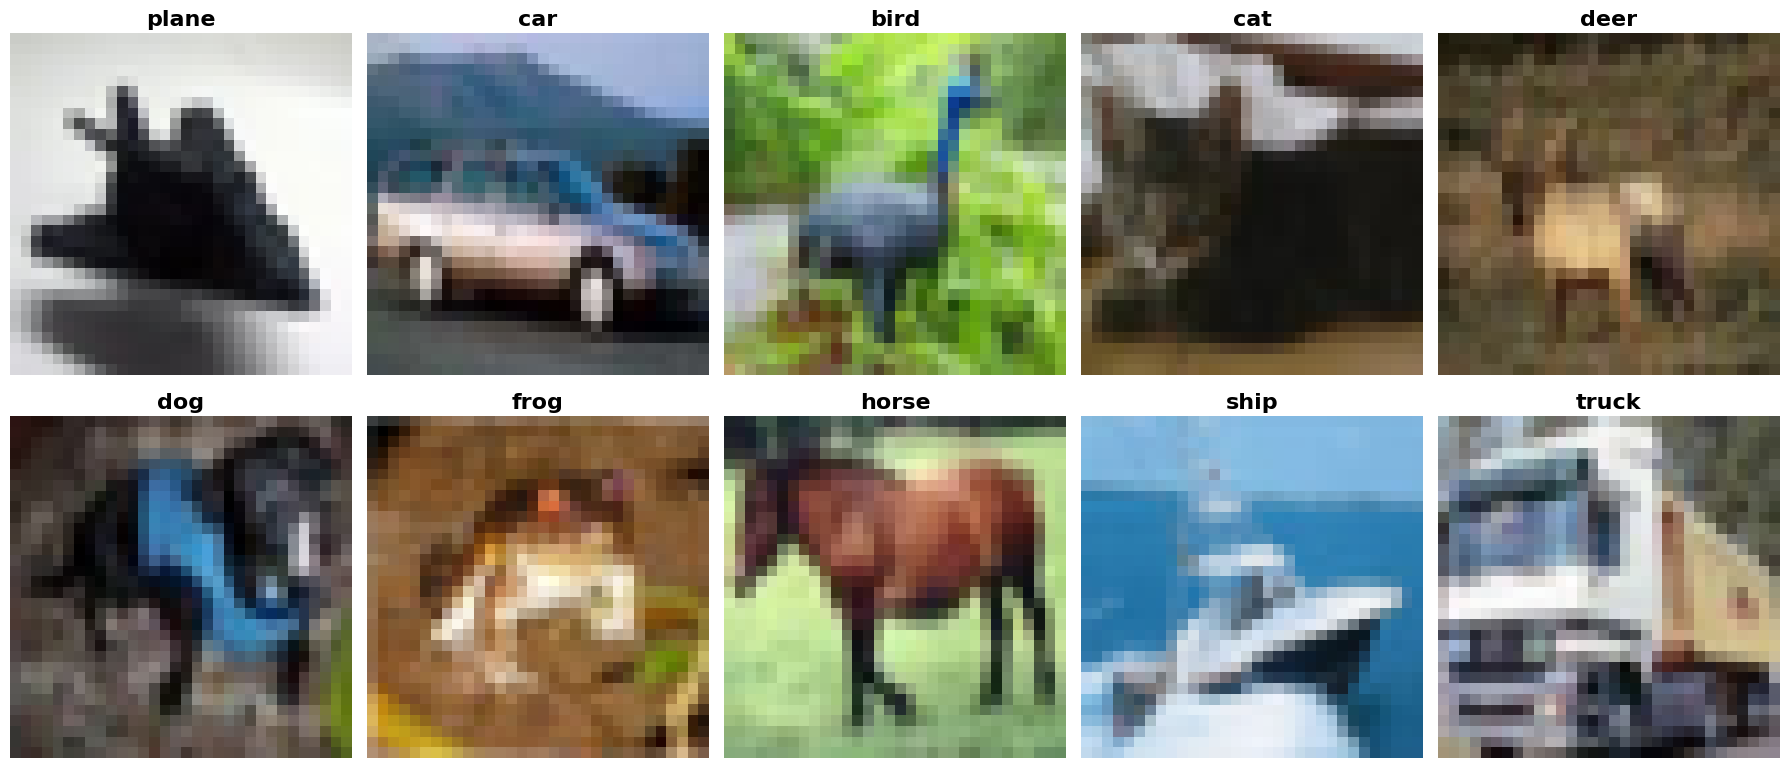

Image shape: torch.Size([3, 32, 32])
✓ All 10 CIFAR-10 classes displayed (2x5 grid)


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

print("Downloading and loading CIFAR-10...")

# Load Training Set
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)

# Load Testing Set
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

print(f"✓ Loaded {len(trainset)} training images")
print(f"✓ Loaded {len(testset)} test images\n")

import matplotlib.pyplot as plt
import numpy as np

# Get one image of each class
examples = []
example_labels = []
found_classes = set()

for img, label in trainset:
    if label not in found_classes:
        examples.append(img)
        example_labels.append(label)
        found_classes.add(label)
    if len(found_classes) == 10:
        break

# Plot the images in a 2x5 grid
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
for i in range(10):
    idx = example_labels.index(i)
    # Get current axis
    ax = axes[i // 5, i % 5]
    
    img = examples[idx].numpy().transpose((1, 2, 0)) # [C,H,W] -> [H,W,C]
    img = img * 0.5 + 0.5     # unnormalize
    ax.imshow(img)
    ax.set_title(classes[i], fontsize=16, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

print(f"Image shape: {examples[0].shape}")
print("✓ All 10 CIFAR-10 classes displayed (2x5 grid)")


<div class="alert alert-info">

### 👀 Data Observations

- **Resolution:** You will notice that the images are not exactly high resolution but they still contain enough information for a model to learn to calssify them to a certain degree.
- **Shape Recap:** Every image consists of 3x32x32 numbers forming a block numbers with dimension`[3, 32, 32]`. The `3` represents the three values needed per pixel to represent colours (how much Red, Green, and Blue per pixel).
- **Real-World Detail:** Notice how different a 'bird' can look depending on its pose, or how 'ships' and 'planes' both often have blue backgrounds. Our model has to learn the difference between water, sky, and the object itself!

</div>

---

## <span style="color: purple;">Step 2 - Single Hidden Layer Neural Network</span>

In the code below, we define our standard neural network model. It treats the image just like a long table of measurements. 

It stretches the image into one long list of **3,072 numbers** (32 x 32 x 3) as input.

In [3]:
class FlatNet(nn.Module):
    def __init__(self):
        super().__init__()
        # The input size is 3*32*32 = 3072 features
        self.linear = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3072, 20),
            nn.ReLU(),
            nn.Linear(20,10)
        )

    def forward(self, x):
        return self.linear(x)

model_flat = FlatNet()
print("✓ Flat model defined")

✓ Flat model defined


---

## <span style="color: purple;">Step 3 - Convolutional Neural Network</span>

A **Convolutional Neural Network (CNN)** is specifically designed for 2D grids. Instead of flattening the features immediately, it uses filters to scan the 3x32x32 tensor to find spatial patterns like edges and textures.

In [4]:
class ConvNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Two convolutional blocks for deeper feature extraction
        self.conv_layers = nn.Sequential(
            # Block 1: Input 3 -> Output 32
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 32x32 -> 16x16
            
            # Block 2: Input 32 -> Output 64
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)  # 16x16 -> 8x8
        )
        
        # Final classifier
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

model_cnn = ConvNet()
print("✓ Deeper CNN model defined")


✓ Deeper CNN model defined


---

## <span style="color: purple;">Step 4 - Train Both Models</span>

Let's see how much faster the CNN can learn compared to the Flat model.

<div class="alert alert-info">

**Run the cell below to train both models. Make sure to re-run Step 2 and Step 3 first.**

</div>

In [5]:
print("Training models for 10 epochs...")

# Use MPS (Silicon GPU) if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
model_flat.to(device)
model_cnn.to(device)

# Re-loading with a larger batch for training speed
trainloader = torch.utils.data.DataLoader(trainset, batch_size=256, shuffle=True)

criterion = nn.CrossEntropyLoss()
optimizer_flat = optim.SGD(model_flat.parameters(), lr=0.01)
optimizer_cnn = optim.SGD(model_cnn.parameters(), lr=0.01)

history_flat = []
history_cnn = []

epochs = 20
for epoch in range(epochs):
    pbar = tqdm(trainloader, desc=f"Epoch {epoch+1}/{epochs}")
    for imgs, lbls in pbar:
        # Move data to device
        imgs, lbls = imgs.to(device), lbls.to(device)
        
        # --- Train FlatNet ---
        optimizer_flat.zero_grad()
        out_flat = model_flat(imgs)
        loss_flat = criterion(out_flat, lbls)
        loss_flat.backward()
        optimizer_flat.step()
        history_flat.append(loss_flat.item())
        
        # --- Train ConvNet ---
        optimizer_cnn.zero_grad()
        out_cnn = model_cnn(imgs)
        loss_cnn = criterion(out_cnn, lbls)
        loss_cnn.backward()
        optimizer_cnn.step()
        history_cnn.append(loss_cnn.item())
        
        # Update progress bar info
        pbar.set_postfix({'flat_loss': f'{loss_flat.item():.3f}', 'cnn_loss': f'{loss_cnn.item():.3f}'})

print("\n✓ Training complete")

Training models for 10 epochs...


Epoch 1/20:   0%|          | 0/196 [00:00<?, ?it/s]

Epoch 2/20:   0%|          | 0/196 [00:00<?, ?it/s]

Epoch 3/20:   0%|          | 0/196 [00:00<?, ?it/s]

Epoch 4/20:   0%|          | 0/196 [00:00<?, ?it/s]

...

Epoch 17/20:   0%|          | 0/196 [00:00<?, ?it/s]

Epoch 18/20:   0%|          | 0/196 [00:00<?, ?it/s]

Epoch 19/20:   0%|          | 0/196 [00:00<?, ?it/s]

Epoch 20/20:   0%|          | 0/196 [00:00<?, ?it/s]


✓ Training complete


---

## <span style="color: purple;">Step 5 - Compare Results</span>

We plot the "Loss" (the error rate). A lower line means the model is getting better at its job.

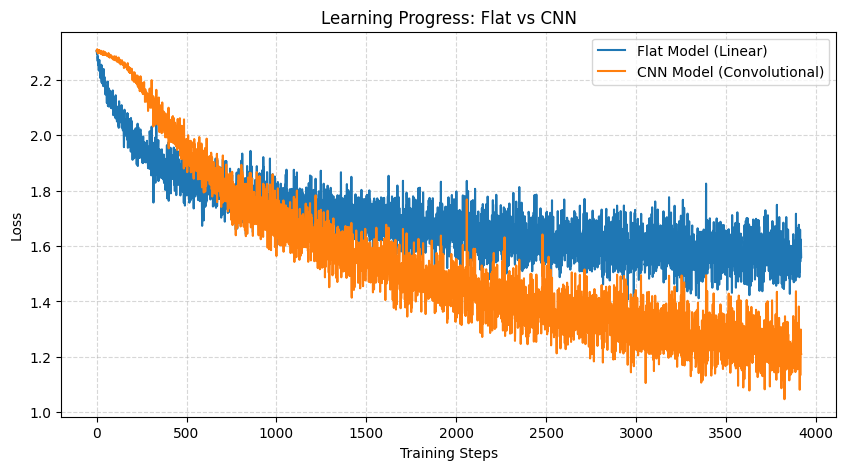

✓ Comparison chart shown


In [6]:
plt.figure(figsize=(10, 5))
plt.plot(history_flat, label='Flat Model (Linear)')
plt.plot(history_cnn, label='CNN Model (Convolutional)')
plt.title('Learning Progress: Flat vs CNN')
plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print("✓ Comparison chart shown")

---

## <span style="color: purple;">Step 6 - Accuracy on Test Data</span>

Training loss tells us how well the model learned the training images, but **Test Accuracy** tells us how well it works on images it has never seen before. This is the ultimate test for an AI.

<div class="alert alert-info">

**Run the cell below** to compare the performance based on the accuracy of the classified labels on new data for each model.

</div>



Evaluating models on Test Set...
FlatNet Accuracy: 44.62%
ConvNet Accuracy: 54.69%


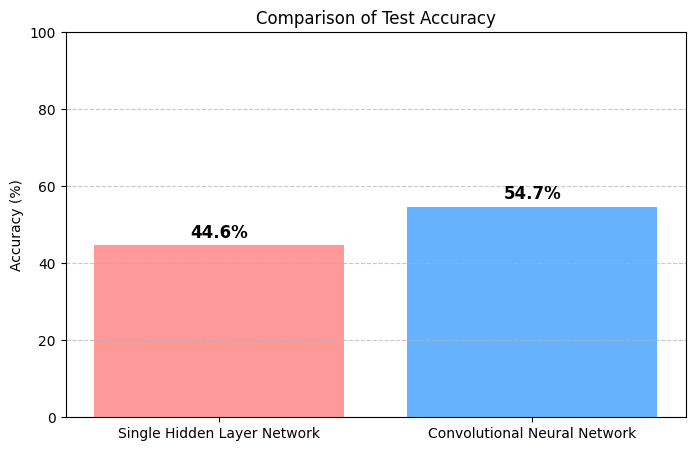

In [9]:
def get_accuracy(model, loader):
    correct = 0
    total = 0
    model.eval() # Set model to evaluation mode
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            outputs = model(imgs)
            _, predicted = torch.max(outputs.data, 1)
            total += lbls.size(0)
            correct += (predicted == lbls).sum().item()
    return 100 * correct / total

print("Evaluating models on Test Set...")
testloader = torch.utils.data.DataLoader(testset, batch_size=256, shuffle=False)

acc_flat = get_accuracy(model_flat, testloader)
acc_cnn = get_accuracy(model_cnn, testloader)

print(f"FlatNet Accuracy: {acc_flat:.2f}%")
print(f"ConvNet Accuracy: {acc_cnn:.2f}%")

# Visualization
plt.figure(figsize=(8, 5))
plt.bar(['Single Hidden Layer Network', 'Convolutional Neural Network'], [acc_flat, acc_cnn], color=['#FF9999', '#66B2FF'])
plt.ylabel('Accuracy (%)')
plt.title('Comparison of Test Accuracy')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, v in enumerate([acc_flat, acc_cnn]):
    plt.text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold', fontsize=12)

plt.show()

<div class="alert alert-info">

### ⚡ The Cost of Performance

As you might notice, training our new, more complex Convolutional Neural Network (CNN) takes significantly more time and processing power than the simple flat network. While the CNN is much more capable at identifying objects, it requires thousands of extra calculations to scan the image grids. 

Additionally, since CNNs have greater ccomplexity, they need more training in both measures of time and data. In real-world AI development, we always have to balance **model accuracy** against **computational expense** (time, electricity, and hardware costs)!

The keen-eyed will notice that the loss value of the CNN did not plateau (flatten out) in Step 5. This indicates that the model is likely to to improve even more if we train it for longer.

</div>

---

## <span style="color: purple;">✅ Summary</span>

Convolutional Neural Networks excel at visual tasks because they respect the grid structure of an image and scan for patterns across colour channels.

| Concept | What is it? |
|---|---|
| RGB Channels | The Red, Green, and Blue layers that make each pixel colourful. |
| Image Features | In an image, every pixel's RGB intensity is an individual measurement (feature) used for prediction. |
| CNN | An AI architecture that preserved the grid shape of an image to find patterns. |
| Kernel | A small grid of numbers (filter) that slides over an image to detect specific features like edges, textures, or shapes. |
| Flat Model | A simpler model that stretches an image into a 1D list, losing its spatial info. |
| CIFAR-10 | A famous dataset of 10 categories of colour photos (32x32 size). |

---

## <span style="color: purple;">🧠 Quiz</span>

Check your understanding of colour channels and CNNs.

In [8]:
from quiz import run_b10_quiz
run_b10_quiz()